# Lab 7. Vector Space Models, SVD, and Latent Semantic Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-07-vector-space-models.ipynb)

This lab accompanies Chapter 7 of **Mathematical Natural Language Processing**.

The main idea of this lab is:

$$
\text{corpus} \longrightarrow \text{document-term matrix} \longrightarrow \text{geometry} \longrightarrow \text{retrieval} \longrightarrow \text{low-rank latent structure}.
$$

You will build a small vector-space search engine from scratch. Then you will use the singular value decomposition to create a low-dimensional latent semantic model.

## How to use this lab

1. Read the mathematical explanation before each code cell.
2. Run all cells in order.
3. Inspect the printed tables and figures.
4. Modify the **Try it yourself** cells.
5. Complete the exercises and mini-project at the end.

This notebook uses only `numpy`, `pandas`, and `matplotlib`, so it should run directly in Google Colab.

## Learning goals

After completing this lab, you should be able to:

- construct a document-term matrix $X \in R^{n \times d}$ from text;
- interpret rows, columns, row space, column space, and Gram matrices in NLP terms;
- compute raw inner-product retrieval scores in matrix form;
- compute cosine similarity and explain why normalization changes the geometry;
- implement TF-IDF as diagonal column scaling;
- compare count search and TF-IDF search;
- compute an SVD and interpret singular values;
- use the Eckart--Young idea to study reconstruction error;
- build a small latent semantic analysis retrieval model;
- visualize document coordinates in a two-dimensional latent space;
- identify strengths and limitations of vector-space models.

## 1. Mathematical background: the document-term matrix

Let

$$
D=\{d_1,d_2,\ldots,d_n\}
$$

be a corpus of $n$ documents, and let

$$
V=\{v_1,v_2,\ldots,v_d\}
$$

be a vocabulary of $d$ tokens. A vector-space model represents document $d_i$ by a vector

$$
x_i=(x_{i1},x_{i2},\ldots,x_{id}) \in R^d.
$$

The full corpus becomes the matrix

$$
X=
\begin{bmatrix}
--- & x_1^T & ---\\
--- & x_2^T & ---\\
& \vdots & \\
--- & x_n^T & ---
\end{bmatrix}
\in R^{n\times d}.
$$

The entry $X_{ij}$ is the weight of token $v_j$ in document $d_i$. It may be a count, a binary indicator, a relative frequency, or a TF-IDF weight.

In this lab, we will mostly use two choices:

1. **count matrix:** $X_{ij}$ is the number of occurrences of term $v_j$ in document $d_i$;
2. **TF-IDF matrix:** count values are rescaled to reduce the influence of common terms.

## 2. Setup

We begin with imports and a simple tokenizer. The tokenizer is intentionally transparent. It lowercases text and keeps alphabetic words.

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 120)

rng = np.random.default_rng(7243)

def tokenize(text):
    """Simple tokenizer for teaching: lowercase and keep alphabetic words."""
    return re.findall(r"[a-z]+", text.lower())

print(tokenize("Vector-space NLP: matrices, SVD, and retrieval!"))

['vector', 'space', 'nlp', 'matrices', 'svd', 'and', 'retrieval']


## 3. A small corpus

The corpus below contains short descriptions about several themes:

- linear algebra and matrices;
- probability and language models;
- SVD and latent semantics;
- document search and retrieval;
- neural language models.

The labels are only used for interpretation and visualization. The retrieval model itself will not use the labels.

In [2]:
corpus = [
    "linear algebra gives vector models for text data",
    "matrices and vector spaces support document representations",
    "probability models describe uncertainty in language",
    "language models use probability and smoothing",
    "singular value decomposition finds latent structure",
    "latent semantic analysis uses matrix factorization",
    "text retrieval compares query vectors with documents",
    "document search ranks texts by cosine similarity",
    "optimization trains modern neural language models",
    "neural networks learn dense representations for language",
    "matrix methods connect algebra geometry and data science",
    "semantic search uses embeddings for related meanings",
]

labels = [
    "linear algebra",
    "linear algebra",
    "probability",
    "probability",
    "svd",
    "svd",
    "search",
    "search",
    "neural",
    "neural",
    "linear algebra",
    "search",
]

doc_names = [f"d{i+1}" for i in range(len(corpus))]

pd.DataFrame({"doc": doc_names, "label": labels, "text": corpus})

,doc,label,text
0,d1,linear algebra,linear algebra gives vector models for text data
1,d2,linear algebra,matrices and vector spaces support document representations
2,d3,probability,probability models describe uncertainty in language
3,d4,probability,language models use probability and smoothing
4,d5,svd,singular value decomposition finds latent structure
5,d6,svd,latent semantic analysis uses matrix factorization
6,d7,search,text retrieval compares query vectors with documents
7,d8,search,document search ranks texts by cosine similarity
8,d9,neural,optimization trains modern neural language models
9,d10,neural,neural networks learn dense representations for language


## 4. Build the count matrix from scratch

For each document, we count how many times each vocabulary token occurs. The vocabulary is the sorted set of all tokens appearing in the corpus.

The resulting matrix has shape

$$
X \in R^{n\times d},
$$

where $n$ is the number of documents and $d$ is the number of vocabulary terms.

In [3]:
tokenized = [tokenize(doc) for doc in corpus]
vocab = sorted({token for doc in tokenized for token in doc})
token_to_col = {token: j for j, token in enumerate(vocab)}

X_counts = np.zeros((len(corpus), len(vocab)), dtype=float)
for i, tokens in enumerate(tokenized):
    counts = Counter(tokens)
    for token, count in counts.items():
        X_counts[i, token_to_col[token]] = count

print("number of documents n =", X_counts.shape[0])
print("vocabulary size d =", X_counts.shape[1])
print("vocabulary:")
print(vocab)

X_counts_df = pd.DataFrame(X_counts, index=doc_names, columns=vocab)
X_counts_df

number of documents n = 12
vocabulary size d = 58
vocabulary:
['algebra', 'analysis', 'and', 'by', 'compares', 'connect', 'cosine', 'data', 'decomposition', 'dense', 'describe', 'document', 'documents', 'embeddings', 'factorization', 'finds', 'for', 'geometry', 'gives', 'in', 'language', 'latent', 'learn', 'linear', 'matrices', 'matrix', 'meanings', 'methods', 'models', 'modern', 'networks', 'neural', 'optimization', 'probability', 'query', 'ranks', 'related', 'representations', 'retrieval', 'science', 'search', 'semantic', 'similarity', 'singular', 'smoothing', 'spaces', 'structure', 'support', 'text', 'texts', 'trains', 'uncertainty', 'use', 'uses', 'value', 'vector', 'vectors', 'with']


,algebra,analysis,and,by,compares,connect,cosine,data,decomposition,dense,describe,document,documents,embeddings,factorization,finds,for,geometry,gives,in,language,latent,learn,linear,matrices,matrix,meanings,methods,models,modern,networks,neural,optimization,probability,query,ranks,related,representations,retrieval,science,search,semantic,similarity,singular,smoothing,spaces,structure,support,text,texts,trains,uncertainty,use,uses,value,vector,vectors,with
d1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
d2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
d3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
d4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
d5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
d6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
d7,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
d8,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
d9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
d10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Sparsity

Text matrices are usually sparse: most entries are zero. The sparsity level is

$$
\text{sparsity}=\frac{\#\{(i,j):X_{ij}=0\}}{nd}.
$$

Large NLP systems use sparse matrix formats. Here we use dense arrays because the matrix is small and easier to inspect.

In [4]:
num_entries = X_counts.size
num_zero = np.sum(X_counts == 0)
sparsity = num_zero / num_entries
print(f"matrix shape: {X_counts.shape}")
print(f"zero entries: {num_zero} out of {num_entries}")
print(f"sparsity: {100*sparsity:.1f}%")

matrix shape: (12, 58)
zero entries: 615 out of 696
sparsity: 88.4%


## 5. Rows, columns, and Gram matrices

A row of $X$ represents a document in vocabulary space. A column of $X$ represents how a term is distributed across documents.

The **document Gram matrix** is

$$
G_D=XX^T.
$$

Its $(i,j)$ entry is the inner product between documents $d_i$ and $d_j$.

The **term Gram matrix** is

$$
G_T=X^TX.
$$

Its $(j,k)$ entry is the co-occurrence inner product between terms $v_j$ and $v_k$.

In [5]:
G_docs = X_counts @ X_counts.T
G_terms = X_counts.T @ X_counts

print("Document Gram matrix shape:", G_docs.shape)
print("Term Gram matrix shape:", G_terms.shape)

pd.DataFrame(G_docs, index=doc_names, columns=doc_names)

Document Gram matrix shape: (12, 12)
Term Gram matrix shape: (58, 58)


,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12
d1,8.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,2.0,1.0
d2,1.0,7.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
d3,1.0,0.0,6.0,3.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0
d4,1.0,1.0,3.0,6.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0
d5,0.0,0.0,0.0,0.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
d6,0.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,1.0,2.0
d7,1.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0
d8,0.0,1.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,1.0
d9,1.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,6.0,2.0,0.0,0.0
d10,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,7.0,0.0,1.0


The term Gram matrix is large when the vocabulary is large. We can inspect a few selected terms.

In [6]:
selected_terms = [t for t in ["matrix", "vector", "language", "models", "search", "semantic", "neural", "probability", "latent"] if t in token_to_col]
idx = [token_to_col[t] for t in selected_terms]

pd.DataFrame(G_terms[np.ix_(idx, idx)], index=selected_terms, columns=selected_terms)

,matrix,vector,language,models,search,semantic,neural,probability,latent
matrix,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
vector,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
language,0.0,0.0,4.0,3.0,0.0,0.0,2.0,2.0,0.0
models,0.0,1.0,3.0,4.0,0.0,0.0,1.0,2.0,0.0
search,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0
semantic,1.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0
neural,0.0,0.0,2.0,1.0,0.0,0.0,2.0,0.0,0.0
probability,0.0,0.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0
latent,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0


## 6. Raw inner-product retrieval

A query is also represented as a vector

$$
q\in R^d.
$$

A raw retrieval score is

$$
s_i=x_i^Tq.
$$

For all documents at once,

$$
s=Xq.
$$

This is fast and simple. However, raw inner products can favor longer documents, because longer documents usually have larger vector norms.

In [7]:
def vectorize_query(query, vocab_index):
    q = np.zeros(len(vocab_index), dtype=float)
    for token in tokenize(query):
        if token in vocab_index:
            q[vocab_index[token]] += 1.0
    return q

def show_ranking(scores, title, top_k=None):
    order = np.argsort(-scores)
    if top_k is not None:
        order = order[:top_k]
    rows = []
    for rank, i in enumerate(order, start=1):
        rows.append({
            "rank": rank,
            "doc": doc_names[i],
            "score": float(scores[i]),
            "label": labels[i],
            "text": corpus[i]
        })
    print(title)
    return pd.DataFrame(rows)

query = "matrix decomposition for latent semantic search"
q_counts = vectorize_query(query, token_to_col)

raw_scores = X_counts @ q_counts
show_ranking(raw_scores, "Raw inner-product search")

Raw inner-product search


,rank,doc,score,label,text
0,1,d6,3.0,svd,latent semantic analysis uses matrix factorization
1,2,d12,3.0,search,semantic search uses embeddings for related meanings
2,3,d5,2.0,svd,singular value decomposition finds latent structure
3,4,d1,1.0,linear algebra,linear algebra gives vector models for text data
4,5,d10,1.0,neural,neural networks learn dense representations for language
5,6,d11,1.0,linear algebra,matrix methods connect algebra geometry and data science
6,7,d8,1.0,search,document search ranks texts by cosine similarity
7,8,d4,0.0,probability,language models use probability and smoothing
8,9,d7,0.0,search,text retrieval compares query vectors with documents
9,10,d2,0.0,linear algebra,matrices and vector spaces support document representations


### Length bias experiment

Now we create a deliberately longer document by repeating some terms. Raw inner products may reward this document just because it contains more tokens.

In [8]:
long_doc = "matrix matrix matrix decomposition latent semantic search search search models models"
long_tokens = tokenize(long_doc)
long_vector = np.zeros(len(vocab))
for token, count in Counter(long_tokens).items():
    if token in token_to_col:
        long_vector[token_to_col[token]] = count

short_doc = "matrix decomposition latent semantic search"
short_tokens = tokenize(short_doc)
short_vector = np.zeros(len(vocab))
for token, count in Counter(short_tokens).items():
    if token in token_to_col:
        short_vector[token_to_col[token]] = count

print("raw score, short document:", short_vector @ q_counts)
print("raw score, long repeated document:", long_vector @ q_counts)
print("short norm:", np.linalg.norm(short_vector))
print("long norm:", np.linalg.norm(long_vector))

raw score, short document: 5.0
raw score, long repeated document: 9.0
short norm: 2.23606797749979
long norm: 5.0


## 7. Cosine similarity and normalization

Cosine similarity compares directions rather than magnitudes:

$$
\operatorname{cos}(x,y)=\frac{x^Ty}{\lVert x\rVert_2\lVert y\rVert_2}.
$$

Define normalized vectors

$$
\widehat{x}=\frac{x}{\lVert x\rVert_2},
\qquad
\widehat{y}=\frac{y}{\lVert y\rVert_2}.
$$

Then

$$
\operatorname{cos}(x,y)=\widehat{x}^T\widehat{y}.
$$

If $\widetilde X$ is the row-normalized document matrix and $\widehat q$ is the normalized query vector, then cosine retrieval is

$$
s=\widetilde X\widehat q.
$$

In [9]:
def row_normalize(A, eps=1e-12):
    norms = np.linalg.norm(A, axis=1, keepdims=True)
    return A / np.maximum(norms, eps)

def normalize_vector(v, eps=1e-12):
    return v / max(np.linalg.norm(v), eps)

X_counts_norm = row_normalize(X_counts)
q_counts_norm = normalize_vector(q_counts)

cos_scores_counts = X_counts_norm @ q_counts_norm
show_ranking(cos_scores_counts, "Cosine search with count vectors")

Cosine search with count vectors


,rank,doc,score,label,text
0,1,d6,0.500000,svd,latent semantic analysis uses matrix factorization
1,2,d12,0.462910,search,semantic search uses embeddings for related meanings
2,3,d5,0.333333,svd,singular value decomposition finds latent structure
3,4,d8,0.154303,search,document search ranks texts by cosine similarity
4,5,d10,0.154303,neural,neural networks learn dense representations for language
5,6,d11,0.144338,linear algebra,matrix methods connect algebra geometry and data science
6,7,d1,0.144338,linear algebra,linear algebra gives vector models for text data
7,8,d4,0.000000,probability,language models use probability and smoothing
8,9,d7,0.000000,search,text retrieval compares query vectors with documents
9,10,d2,0.000000,linear algebra,matrices and vector spaces support document representations


In [10]:
short_cos = normalize_vector(short_vector) @ q_counts_norm
long_cos = normalize_vector(long_vector) @ q_counts_norm

print("cosine score, short document:", round(float(short_cos), 4))
print("cosine score, long repeated document:", round(float(long_cos), 4))
print("Cosine reduces, but does not completely remove, all effects of repetition.")

cosine score, short document: 0.9129
cosine score, long repeated document: 0.7348
Cosine reduces, but does not completely remove, all effects of repetition.


## 8. TF-IDF as diagonal column scaling

Raw counts treat all words equally. But some words are more informative than others. For example, a word that appears in nearly every document should usually receive less weight.

The document frequency of term $v_j$ is

$$
\operatorname{df}_j=\#\{i:X_{ij}>0\}.
$$

A smoothed inverse document frequency is

$$
\operatorname{idf}_j=\log\left(\frac{1+n}{1+\operatorname{df}_j}\right)+1.
$$

The TF-IDF matrix is

$$
X^{\text{tfidf}}_{ij}=X_{ij}\operatorname{idf}_j.
$$

In matrix form, this is a diagonal column scaling:

$$
X^{\text{tfidf}}=XW,
$$

where

$$
W=\operatorname{diag}(\operatorname{idf}_1,\ldots,\operatorname{idf}_d).
$$

In [11]:
def tfidf_transform(X):
    n = X.shape[0]
    df = np.sum(X > 0, axis=0)
    idf = np.log((1 + n) / (1 + df)) + 1
    X_tfidf = X * idf
    return X_tfidf, idf, df

X_tfidf, idf, df = tfidf_transform(X_counts)

idf_table = pd.DataFrame({
    "term": vocab,
    "document_frequency": df.astype(int),
    "idf": idf
}).sort_values(["idf", "term"], ascending=[False, True])

idf_table.head(15)

,term,document_frequency,idf
1,analysis,1,2.871802
3,by,1,2.871802
4,compares,1,2.871802
5,connect,1,2.871802
6,cosine,1,2.871802
8,decomposition,1,2.871802
9,dense,1,2.871802
10,describe,1,2.871802
12,documents,1,2.871802
13,embeddings,1,2.871802


Terms that appear in fewer documents have higher IDF values. Now we compare count-cosine search with TF-IDF-cosine search.

In [12]:
q_tfidf = q_counts * idf
X_tfidf_norm = row_normalize(X_tfidf)
q_tfidf_norm = normalize_vector(q_tfidf)

tfidf_scores = X_tfidf_norm @ q_tfidf_norm

count_ranking = show_ranking(cos_scores_counts, "Count-cosine ranking")
tfidf_ranking = show_ranking(tfidf_scores, "TF-IDF-cosine ranking")

comparison = count_ranking[["rank", "doc", "score", "label", "text"]].rename(columns={"rank": "count_rank", "score": "count_score"}).merge(
    tfidf_ranking[["rank", "doc", "score"]].rename(columns={"rank": "tfidf_rank", "score": "tfidf_score"}),
    on="doc"
).sort_values("tfidf_rank")

comparison

Count-cosine ranking
TF-IDF-cosine ranking


,count_rank,doc,count_score,label,text,tfidf_rank,tfidf_score
0,1,d6,0.500000,svd,latent semantic analysis uses matrix factorization,1,0.467475
1,2,d12,0.462910,search,semantic search uses embeddings for related meanings,2,0.400657
2,3,d5,0.333333,svd,singular value decomposition finds latent structure,3,0.340981
3,4,d8,0.154303,search,document search ranks texts by cosine similarity,4,0.136247
5,6,d11,0.144338,linear algebra,matrix methods connect algebra geometry and data science,5,0.133068
4,5,d10,0.154303,neural,neural networks learn dense representations for language,6,0.115206
6,7,d1,0.144338,linear algebra,linear algebra gives vector models for text data,7,0.110543
7,8,d4,0.000000,probability,language models use probability and smoothing,8,0.000000
8,9,d7,0.000000,search,text retrieval compares query vectors with documents,9,0.000000
9,10,d2,0.000000,linear algebra,matrices and vector spaces support document representations,10,0.000000


## 9. Singular value decomposition

The singular value decomposition writes a matrix as

$$
X=U\Sigma V^T.
$$

For a document-term matrix:

- columns of $U$ describe orthogonal directions among documents;
- columns of $V$ describe orthogonal directions among terms;
- singular values in $\Sigma$ measure the strength of each direction.

The SVD also diagonalizes the Gram matrices:

$$
XX^T=U\Sigma^2U^T,
\qquad
X^TX=V\Sigma^2V^T.
$$

We apply SVD to the TF-IDF matrix, because TF-IDF is usually more informative than raw counts for retrieval.

In [13]:
X = X_tfidf.copy()
U, singular_values, Vt = np.linalg.svd(X, full_matrices=False)

energy = singular_values**2
energy_fraction = energy / energy.sum()
cumulative_energy = np.cumsum(energy_fraction)

sv_table = pd.DataFrame({
    "component": np.arange(1, len(singular_values) + 1),
    "singular_value": singular_values,
    "energy_fraction": energy_fraction,
    "cumulative_energy": cumulative_energy
})

sv_table

,component,singular_value,energy_fraction,cumulative_energy
0,1,8.774328,0.138628,0.138628
1,2,7.783206,0.109079,0.247707
2,3,7.695842,0.106644,0.354351
3,4,7.491826,0.101065,0.455416
4,5,7.376585,0.097979,0.553395
5,6,6.890122,0.085483,0.638878
6,7,6.716807,0.081236,0.720114
7,8,6.262816,0.070626,0.790740
8,9,6.179061,0.068749,0.859489
9,10,5.434103,0.053172,0.912661


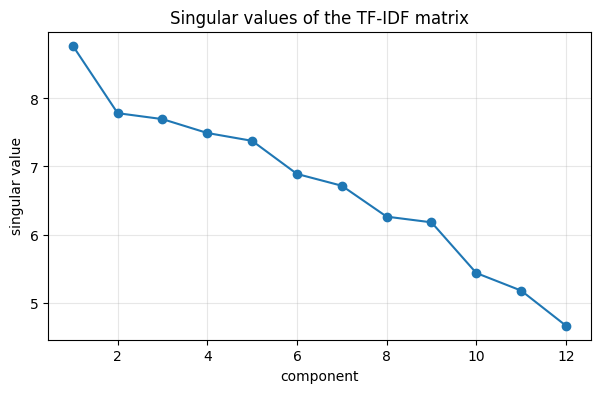

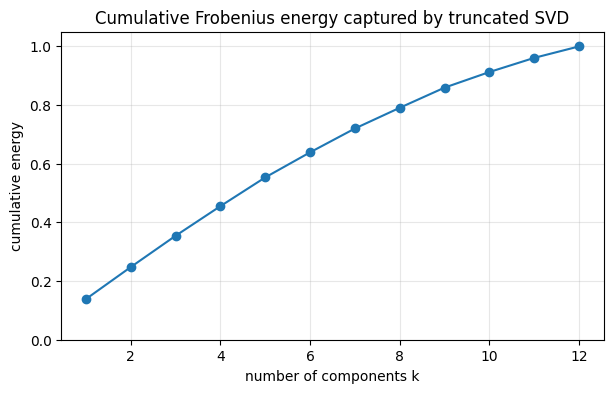

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(sv_table["component"], sv_table["singular_value"], marker="o")
plt.xlabel("component")
plt.ylabel("singular value")
plt.title("Singular values of the TF-IDF matrix")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(sv_table["component"], sv_table["cumulative_energy"], marker="o")
plt.xlabel("number of components k")
plt.ylabel("cumulative energy")
plt.title("Cumulative Frobenius energy captured by truncated SVD")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

## 10. Low-rank approximation and reconstruction error

The rank-$k$ truncated SVD approximation is

$$
X_k=U_k\Sigma_kV_k^T.
$$

The Eckart--Young--Mirsky theorem says that $X_k$ is the best rank-$k$ approximation to $X$ in Frobenius norm:

$$
X_k=\arg\min_{\operatorname{rank}(A)\le k}\lVert X-A\rVert_F.
$$

The squared error is

$$
\lVert X-X_k\rVert_F^2=\sum_{j=k+1}^r \sigma_j^2.
$$

In [15]:
def svd_reconstruction(X, k):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return (U[:, :k] * s[:k]) @ Vt[:k, :]

rows = []
for k in range(1, min(X.shape) + 1):
    Xk = svd_reconstruction(X, k)
    error = np.linalg.norm(X - Xk, ord="fro")
    relative_error = error / np.linalg.norm(X, ord="fro")
    captured = 1 - relative_error**2
    rows.append({
        "k": k,
        "frobenius_error": error,
        "relative_error": relative_error,
        "energy_captured": captured
    })

reconstruction_df = pd.DataFrame(rows)
reconstruction_df.head(12)

,k,frobenius_error,relative_error,energy_captured
0,1,2.187174e+01,9.281012e-01,0.138628
1,2,2.044003e+01,8.673481e-01,0.247707
2,3,1.893591e+01,8.035228e-01,0.354351
3,4,1.739084e+01,7.379595e-01,0.455416
4,5,1.574888e+01,6.682850e-01,0.553395
5,6,1.416169e+01,6.009344e-01,0.638878
6,7,1.246748e+01,5.290425e-01,0.720114
7,8,1.078031e+01,4.574497e-01,0.790740
8,9,8.833706e+00,3.748477e-01,0.859489
9,10,6.964545e+00,2.955321e-01,0.912661


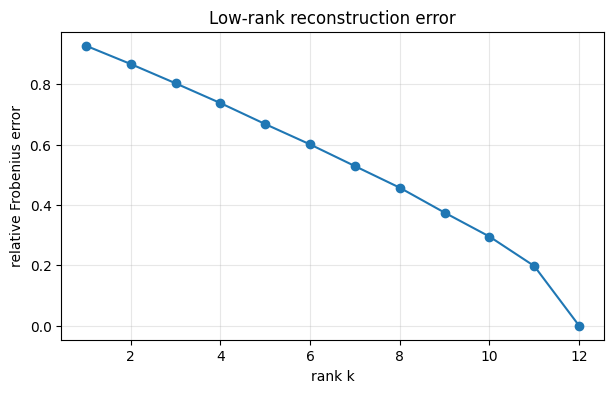

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(reconstruction_df["k"], reconstruction_df["relative_error"], marker="o")
plt.xlabel("rank k")
plt.ylabel("relative Frobenius error")
plt.title("Low-rank reconstruction error")
plt.grid(True, alpha=0.3)
plt.show()

## 11. Latent semantic analysis

Latent semantic analysis, or LSA, uses a truncated SVD to represent documents in a lower-dimensional space.

If

$$
X\approx U_k\Sigma_kV_k^T,
$$

then the document coordinates are often taken to be

$$
Z=U_k\Sigma_k=XV_k.
$$

A query vector $q$ can be projected into the same latent coordinate system:

$$
z_q=q^TV_k.
$$

Then search can be done by comparing $z_q$ with the document coordinates $z_i$.

In [17]:
def truncated_svd_coordinates(X, k):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    Vk = Vt[:k, :].T
    Z_docs = X @ Vk
    return Z_docs, Vk, s[:k]

k = 2
Z2, V2, s2 = truncated_svd_coordinates(X_tfidf, k=k)

coords = pd.DataFrame({
    "doc": doc_names,
    "x": Z2[:, 0],
    "y": Z2[:, 1],
    "label": labels,
    "text": corpus
})
coords

,doc,x,y,label,text
0,d1,-4.481824,-0.523062,linear algebra,linear algebra gives vector models for text data
1,d2,-2.842172,0.298636,linear algebra,matrices and vector spaces support document representations
2,d3,-1.999559,-2.478770,probability,probability models describe uncertainty in language
3,d4,-2.474820,-2.110682,probability,language models use probability and smoothing
4,d5,-0.295345,1.448677,svd,singular value decomposition finds latent structure
5,d6,-1.440584,3.157804,svd,latent semantic analysis uses matrix factorization
6,d7,-1.272591,-0.634817,search,text retrieval compares query vectors with documents
7,d8,-1.255787,3.593480,search,document search ranks texts by cosine similarity
8,d9,-2.030618,-2.356741,neural,optimization trains modern neural language models
9,d10,-2.710536,-1.513781,neural,neural networks learn dense representations for language


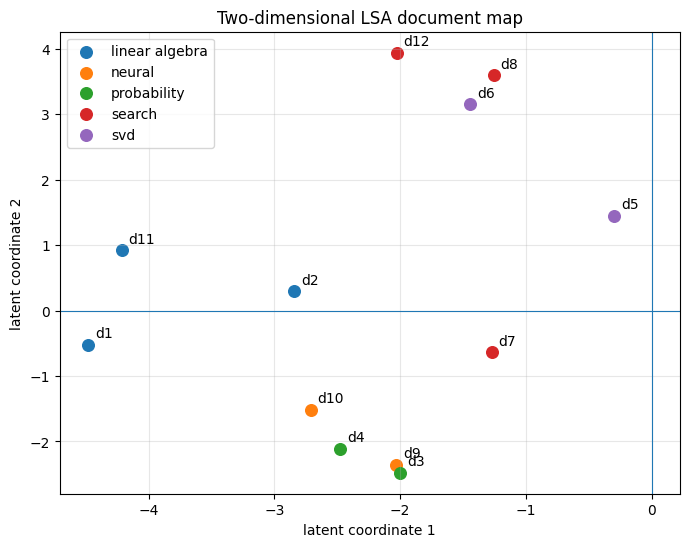

In [18]:
plt.figure(figsize=(8, 6))
for label in sorted(set(labels)):
    mask = np.array(labels) == label
    plt.scatter(Z2[mask, 0], Z2[mask, 1], label=label, s=70)

for i, name in enumerate(doc_names):
    plt.annotate(name, (Z2[i, 0], Z2[i, 1]), xytext=(5, 5), textcoords="offset points")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("latent coordinate 1")
plt.ylabel("latent coordinate 2")
plt.title("Two-dimensional LSA document map")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Low-rank retrieval

In TF-IDF search, we compare documents and queries in the original vocabulary space.

In LSA search, we first project both documents and query into a lower-dimensional latent space.

For rank $k$:

$$
Z=XV_k,
\qquad
z_q=q^TV_k.
$$

After normalization, cosine scores are

$$
s=\widehat Z\widehat z_q.
$$

In [19]:
def lsa_scores(X_weighted, q_weighted, k):
    U, s, Vt = np.linalg.svd(X_weighted, full_matrices=False)
    Vk = Vt[:k, :].T
    Z_docs = X_weighted @ Vk
    z_query = q_weighted @ Vk
    Zn = row_normalize(Z_docs)
    zqn = normalize_vector(z_query)
    return Zn @ zqn

for k in [1, 2, 3, 4, 6]:
    scores = lsa_scores(X_tfidf, q_tfidf, k=k)
    print(f"\nLSA rank k={k}")
    display(show_ranking(scores, f"LSA rank {k}", top_k=6))


LSA rank k=1
LSA rank 1


,rank,doc,score,label,text
0,1,d1,1.0,linear algebra,linear algebra gives vector models for text data
1,2,d2,1.0,linear algebra,matrices and vector spaces support document representations
2,3,d3,1.0,probability,probability models describe uncertainty in language
3,4,d4,1.0,probability,language models use probability and smoothing
4,5,d5,1.0,svd,singular value decomposition finds latent structure
5,6,d6,1.0,svd,latent semantic analysis uses matrix factorization



LSA rank k=2
LSA rank 2


,rank,doc,score,label,text
0,1,d12,0.995642,search,semantic search uses embeddings for related meanings
1,2,d6,0.990143,svd,latent semantic analysis uses matrix factorization
2,3,d8,0.973135,search,document search ranks texts by cosine similarity
3,4,d5,0.933264,svd,singular value decomposition finds latent structure
4,5,d11,0.706323,linear algebra,matrix methods connect algebra geometry and data science
5,6,d2,0.623495,linear algebra,matrices and vector spaces support document representations



LSA rank k=3
LSA rank 3


,rank,doc,score,label,text
0,1,d6,0.975595,svd,latent semantic analysis uses matrix factorization
1,2,d12,0.964494,search,semantic search uses embeddings for related meanings
2,3,d5,0.918100,svd,singular value decomposition finds latent structure
3,4,d8,0.849030,search,document search ranks texts by cosine similarity
4,5,d2,0.628758,linear algebra,matrices and vector spaces support document representations
5,6,d11,0.425511,linear algebra,matrix methods connect algebra geometry and data science



LSA rank k=4
LSA rank 4


,rank,doc,score,label,text
0,1,d6,0.961313,svd,latent semantic analysis uses matrix factorization
1,2,d12,0.936993,search,semantic search uses embeddings for related meanings
2,3,d5,0.874782,svd,singular value decomposition finds latent structure
3,4,d8,0.750935,search,document search ranks texts by cosine similarity
4,5,d2,0.623202,linear algebra,matrices and vector spaces support document representations
5,6,d11,0.409368,linear algebra,matrix methods connect algebra geometry and data science



LSA rank k=6
LSA rank 6


,rank,doc,score,label,text
0,1,d6,0.951830,svd,latent semantic analysis uses matrix factorization
1,2,d12,0.747941,search,semantic search uses embeddings for related meanings
2,3,d5,0.564039,svd,singular value decomposition finds latent structure
3,4,d11,0.235319,linear algebra,matrix methods connect algebra geometry and data science
4,5,d8,0.222910,search,document search ranks texts by cosine similarity
5,6,d1,0.215866,linear algebra,linear algebra gives vector models for text data


### Compare the top rankings

The same query can produce different rankings depending on the geometry:

1. count-cosine geometry;
2. TF-IDF-cosine geometry;
3. low-rank LSA geometry.

In [20]:
def ranking_order(scores):
    return list(np.argsort(-scores))

def top_docs(scores, k=5):
    return [doc_names[i] for i in np.argsort(-scores)[:k]]

lsa2_scores = lsa_scores(X_tfidf, q_tfidf, k=2)
lsa4_scores = lsa_scores(X_tfidf, q_tfidf, k=4)

summary = pd.DataFrame({
    "method": ["count cosine", "tfidf cosine", "LSA k=2", "LSA k=4"],
    "top_5_docs": [
        ", ".join(top_docs(cos_scores_counts)),
        ", ".join(top_docs(tfidf_scores)),
        ", ".join(top_docs(lsa2_scores)),
        ", ".join(top_docs(lsa4_scores)),
    ]
})
summary

,method,top_5_docs
0,count cosine,"d6, d12, d5, d8, d10"
1,tfidf cosine,"d6, d12, d5, d8, d11"
2,LSA k=2,"d12, d6, d8, d5, d11"
3,LSA k=4,"d6, d12, d5, d8, d2"


## 13. Term coordinates and nearest terms

The right singular vectors $V_k$ describe latent directions among terms. We can assign a simple latent coordinate to each term using rows of

$$
V_k\Sigma_k.
$$

This is not the same as a modern neural word embedding, but it is an important classical predecessor.

In [21]:
def term_coordinates(X_weighted, k):
    U, s, Vt = np.linalg.svd(X_weighted, full_matrices=False)
    Vk = Vt[:k, :].T
    return Vk * s[:k]

T2 = term_coordinates(X_tfidf, k=2)
term_coords = pd.DataFrame({
    "term": vocab,
    "x": T2[:, 0],
    "y": T2[:, 1]
})

interesting = ["matrix", "vector", "latent", "semantic", "search", "language", "probability", "neural", "models", "retrieval"]
term_coords[term_coords["term"].isin(interesting)].sort_values("term")

,term,x,y
20,language,-2.053842,-2.125548
21,latent,-0.487945,1.459699
25,matrix,-1.589555,1.293362
28,models,-2.448604,-1.876632
31,neural,-1.332670,-1.226488
33,probability,-1.257683,-1.454303
38,retrieval,-0.416514,-0.234231
40,search,-0.922832,2.387488
41,semantic,-0.974776,2.249431
55,vector,-2.058670,-0.071116


In [22]:
def nearest_terms(target, term_coord_matrix, vocab, top_k=8):
    if target not in token_to_col:
        raise ValueError(f"{target!r} is not in the vocabulary")
    target_vec = term_coord_matrix[token_to_col[target]]
    norms = np.linalg.norm(term_coord_matrix, axis=1) * max(np.linalg.norm(target_vec), 1e-12)
    sims = (term_coord_matrix @ target_vec) / np.maximum(norms, 1e-12)
    order = np.argsort(-sims)
    rows = []
    for j in order[:top_k]:
        rows.append({"term": vocab[j], "cosine_in_latent_space": float(sims[j])})
    return pd.DataFrame(rows)

for target in ["matrix", "language", "search"]:
    print(f"\nNearest terms to: {target}")
    display(nearest_terms(target, T2, vocab, top_k=8))


Nearest terms to: matrix


,term,cosine_in_latent_space
0,matrix,1.000000
1,document,0.990696
2,geometry,0.904423
3,connect,0.904423
4,methods,0.904423
5,science,0.904423
6,for,0.898581
7,embeddings,0.896194



Nearest terms to: language


,term,cosine_in_latent_space
0,language,1.000000
1,smoothing,0.999323
2,use,0.999323
3,probability,0.998476
4,neural,0.998282
5,optimization,0.993319
6,modern,0.993319
7,trains,0.993319



Nearest terms to: search


,term,cosine_in_latent_space
0,search,1.000000
1,analysis,0.999877
2,factorization,0.999877
3,semantic,0.999197
4,uses,0.999197
5,latent,0.998931
6,meanings,0.998245
7,embeddings,0.998245


## 14. Vocabulary mismatch and a failure case

Classical vector-space models depend heavily on vocabulary overlap. If a query uses words that never occur in the corpus, the query vector may lose most of its meaning.

For example, suppose the query uses `automobile`, but the corpus only uses `car`. A bag-of-words model will not know that these words are related unless the relation is somehow learned from context or supplied externally.

Let us test this idea with a query whose terms mostly do not appear in the corpus.

In [23]:
failure_query = "automobile meaning representation"
q_fail = vectorize_query(failure_query, token_to_col)
print("tokens:", tokenize(failure_query))
print("nonzero query coordinates:", int(np.count_nonzero(q_fail)))
print("known query terms:", [t for t in tokenize(failure_query) if t in token_to_col])

if np.count_nonzero(q_fail) == 0:
    print("The query has no known vocabulary terms, so this vector-space model cannot rank documents meaningfully.")
else:
    q_fail_tfidf = q_fail * idf
    fail_scores = X_tfidf_norm @ normalize_vector(q_fail_tfidf)
    display(show_ranking(fail_scores, "TF-IDF ranking for vocabulary-mismatch query", top_k=8))

tokens: ['automobile', 'meaning', 'representation']
nonzero query coordinates: 0
known query terms: []
The query has no known vocabulary terms, so this vector-space model cannot rank documents meaningfully.


## 15. Try it yourself

Modify the query below and compare the rankings. Good test queries include:

- `probability smoothing language model`
- `cosine document search`
- `neural representations for text`
- `algebra matrix geometry`
- a query with synonyms that are not in the corpus

In [24]:
my_query = "probability smoothing language model"
q_my_counts = vectorize_query(my_query, token_to_col)
q_my_tfidf = q_my_counts * idf

my_count_scores = X_counts_norm @ normalize_vector(q_my_counts)
my_tfidf_scores = X_tfidf_norm @ normalize_vector(q_my_tfidf)
my_lsa_scores = lsa_scores(X_tfidf, q_my_tfidf, k=3)

print("Known query terms:", [t for t in tokenize(my_query) if t in token_to_col])

display(show_ranking(my_count_scores, "My query: count cosine", top_k=5))
display(show_ranking(my_tfidf_scores, "My query: TF-IDF cosine", top_k=5))
display(show_ranking(my_lsa_scores, "My query: LSA k=3", top_k=5))

Known query terms: ['probability', 'smoothing', 'language']
My query: count cosine


,rank,doc,score,label,text
0,1,d4,0.707107,probability,language models use probability and smoothing
1,2,d3,0.471405,probability,probability models describe uncertainty in language
2,3,d9,0.235702,neural,optimization trains modern neural language models
3,4,d10,0.218218,neural,neural networks learn dense representations for language
4,5,d5,0.000000,svd,singular value decomposition finds latent structure


My query: TF-IDF cosine


,rank,doc,score,label,text
0,1,d4,0.720489,probability,language models use probability and smoothing
1,2,d3,0.374863,probability,probability models describe uncertainty in language
2,3,d9,0.144696,neural,optimization trains modern neural language models
3,4,d10,0.133086,neural,neural networks learn dense representations for language
4,5,d5,0.000000,svd,singular value decomposition finds latent structure


My query: LSA k=3


,rank,doc,score,label,text
0,1,d3,0.999473,probability,probability models describe uncertainty in language
1,2,d9,0.998284,neural,optimization trains modern neural language models
2,3,d4,0.974441,probability,language models use probability and smoothing
3,4,d10,0.941024,neural,neural networks learn dense representations for language
4,5,d2,0.619401,linear algebra,matrices and vector spaces support document representations


## 16. Reflection: what changed when we changed the representation?

The same text collection can produce different results depending on the mathematical representation.

- Counts measure direct overlap.
- Cosine similarity compares directions and reduces length bias.
- TF-IDF rescales vocabulary axes.
- SVD projects the data onto a low-dimensional latent subspace.

None of these choices is neutral. Each choice encodes assumptions about what similarity should mean.

## Exercises

### Conceptual exercises

1. In a document-term matrix $X\in R^{n\times d}$, what do the rows represent? What do the columns represent?
2. Explain the NLP meaning of $XX^T$ and $X^TX$.
3. Why can raw inner products favor long documents?
4. Why does cosine similarity compare direction rather than magnitude?
5. Explain TF-IDF as a diagonal column-scaling operation.
6. Why are singular values useful for measuring low-rank structure?
7. What does LSA gain by projecting onto a low-dimensional subspace?
8. Give one limitation of LSA caused by the bag-of-words assumption.

### Mathematical exercises

1. Prove that cosine similarity is the inner product of normalized vectors.
2. Let
   $$
   X=\begin{bmatrix}
   1&1&0\\
   1&0&1\\
   0&1&1
   \end{bmatrix}.
   $$
   Compute $XX^T$ and the cosine similarity matrix.
3. If $X=U\Sigma V^T$, show that $XX^T=U\Sigma^2U^T$ and $X^TX=V\Sigma^2V^T$.
4. If $X_k=U_k\Sigma_kV_k^T$, show that $X_kV_k=U_k\Sigma_k$.
5. Let $q\in R^d$ be a query vector. Derive the latent query coordinate $z_q=q^TV_k$.
6. Explain why $\sum_{j=1}^k \sigma_j^2/\sum_{j=1}^r \sigma_j^2$ is a fraction of Frobenius energy.

### Computational exercises

1. Add five new documents to the corpus and rebuild the vocabulary and matrix.
2. Compare search rankings using counts, TF-IDF, and LSA with $k=2,3,4$.
3. Remove common words such as `models`, `language`, and `data`. How do rankings change?
4. Plot the first two LSA coordinates for the expanded corpus.
5. Find nearest terms for three target terms using latent term coordinates.
6. Create a failure query and explain exactly why it fails.

## Mini-project: a small mathematical search engine

Build a small search engine for a focused corpus. Possible corpora include:

- course descriptions;
- advising FAQ questions;
- research abstracts;
- textbook section summaries;
- job descriptions;
- news headlines.

Your report should include:

1. the tokenization rule;
2. the vocabulary size;
3. the document-term matrix shape;
4. a table of high-IDF terms;
5. at least three queries;
6. count-cosine rankings;
7. TF-IDF-cosine rankings;
8. LSA rankings for at least two choices of $k$;
9. one visualization of the low-dimensional document coordinates;
10. one failure case and a mathematical explanation of the failure.

A strong report should not only show rankings. It should explain how the geometry of the representation affects the rankings.

## AI-assisted learning activity

Use an AI tool as a critic, not as an answer machine. Try this prompt:

> I built a search engine using TF-IDF cosine similarity and LSA. What mathematical assumptions am I making about language, similarity, word order, synonymy, document length, and rare terms? Give examples of when these assumptions might fail.

Then compare the AI response with your own experiments from this lab. In your notes, identify at least one point where the AI explanation was useful and at least one point where it was too vague.